##### Must do when training a model

- Must optimise your model to find the optimal parameters -> do this either using an optimization method (gradient descent, standard error, etc..) or brute force (GridSearchCV)

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from imblearn.over_sampling import SMOTE, ADASYN

### Import trainingset

In [2]:
x = Path('/Users/arthur/Library/Mobile Documents/com~apple~CloudDocs/Documents/Marseille/aMU/M1/Stage/2026_09_09_variable_trainingset_2.csv')
df = pd.read_csv(x).drop(columns='Unnamed: 0')
df = df.iloc[0::1792, :]

id = df.loc[:, 'condition_id']
X = df.drop(columns=['condition_id', 'condition'])
y = df.loc[:, 'condition']

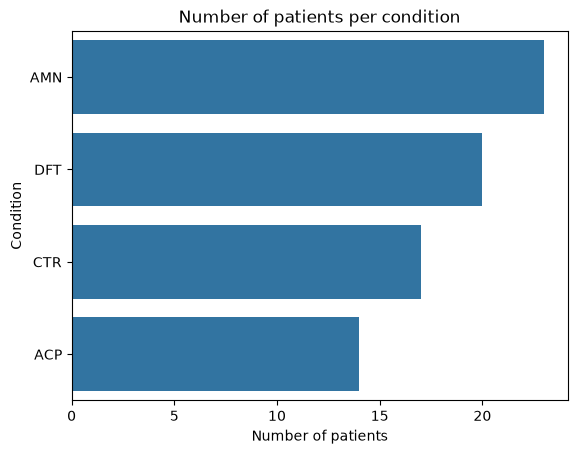

In [ ]:
# (df.condition.value_counts()/6).plot.barh()

ax = sns.barplot(data = df.condition.value_counts()/6, orient='h')
ax.set(xlabel='Number of patients', ylabel='Condition', title='Number of patients per condition')

# plt.savefig('figures/missing_conds.png', dpi=150)

### Rebalancing dataset

In [7]:
X_resampled, y_resampled = SMOTE().fit_resample(X, y)

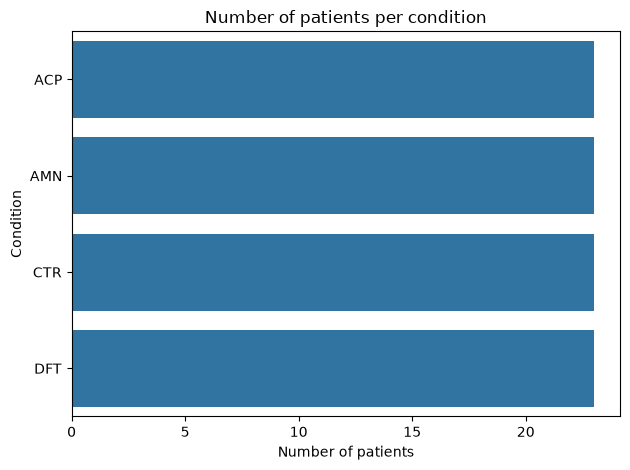

In [ ]:
test = pd.concat([X_resampled, y_resampled], axis=1)

ax = sns.barplot(data = test.condition.value_counts()/6, orient='h')
ax.set(xlabel='Number of patients', ylabel='Condition', title='Number of patients per condition')

# plt.savefig('figures/balanced_whole_dataset_barh', dpi=150)

plt.tight_layout()

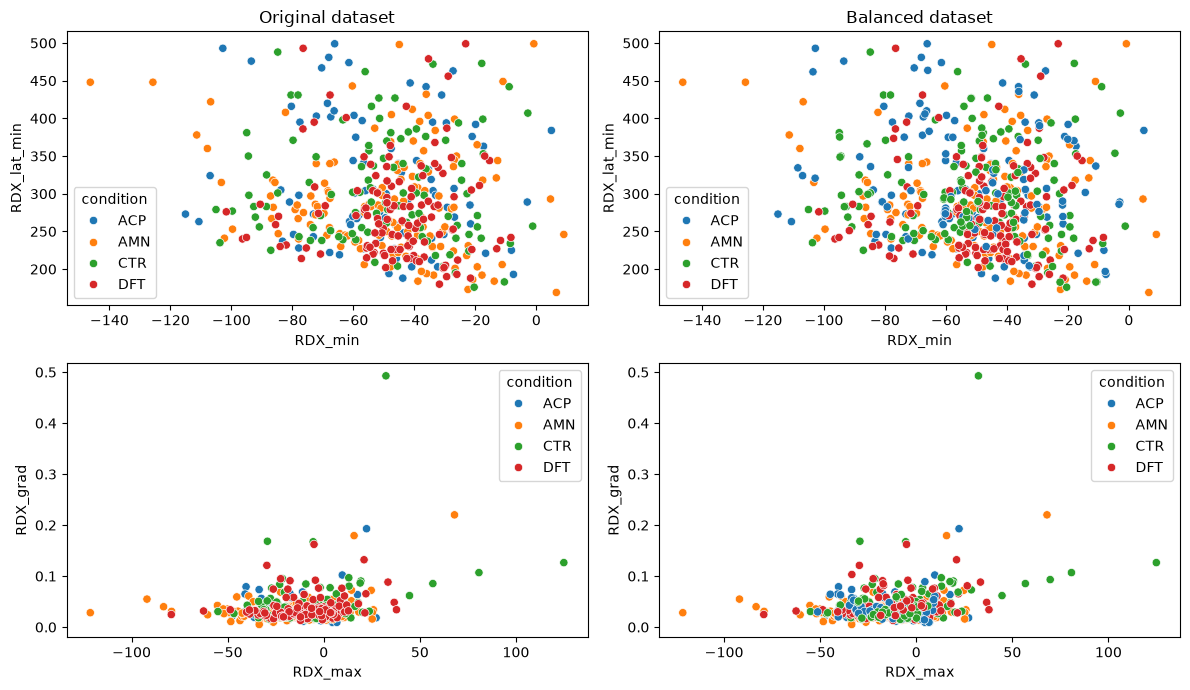

In [25]:
fig, ax = plt.subplots(2, 2, figsize=(12, 7))


sns.scatterplot(df, x='RDX_min', y='RDX_lat_min', ax=ax[0][0], hue='condition')
sns.scatterplot(df, x='RDX_max', y='RDX_grad', ax=ax[1][0], hue='condition')

sns.scatterplot(test, x='RDX_min', y='RDX_lat_min', ax=ax[0][1], hue='condition')
sns.scatterplot(test, x='RDX_max', y='RDX_grad', ax=ax[1][1], hue='condition')

ax[0][0].set_title('Original dataset')
ax[0][1].set_title('Balanced dataset')

plt.tight_layout()

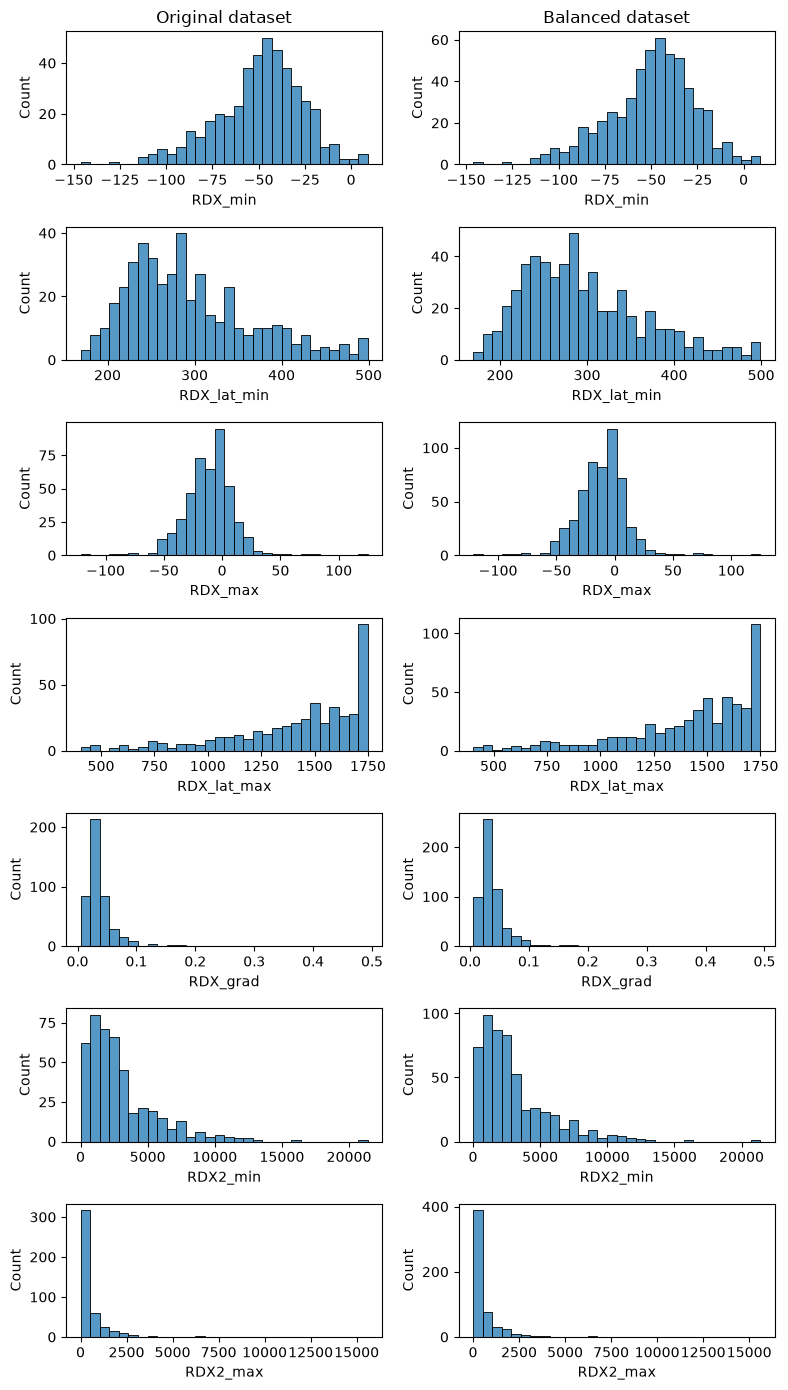

In [ ]:
fig, ax = plt.subplots(7, 2, figsize=(8, 14))

sns.histplot(df, x='RDX_min', bins=30, ax=ax[0][0])
sns.histplot(test, x='RDX_min', bins=30, ax=ax[0][1])

sns.histplot(df, x='RDX_lat_min', bins=30, ax=ax[1][0])
sns.histplot(test, x='RDX_lat_min', bins=30, ax=ax[1][1])

sns.histplot(df, x='RDX_max', bins=30, ax=ax[2][0])
sns.histplot(test, x='RDX_max', bins=30, ax=ax[2][1])

sns.histplot(df, x='RDX_lat_max', bins=30, ax=ax[3][0])
sns.histplot(test, x='RDX_lat_max', bins=30, ax=ax[3][1])

sns.histplot(df, x='RDX_grad', bins=30, ax=ax[4][0])
sns.histplot(test, x='RDX_grad', bins=30, ax=ax[4][1])

sns.histplot(df, x='RDX2_min', bins=30, ax=ax[5][0])
sns.histplot(test, x='RDX2_min', bins=30, ax=ax[5][1])

sns.histplot(df, x='RDX2_max', bins=30, ax=ax[6][0])
sns.histplot(test, x='RDX2_max', bins=30, ax=ax[6][1])

ax[0][0].set_title('Original dataset')
ax[0][1].set_title('Balanced dataset')

# plt.savefig('figures/balanced_whole_dataset_hist', dpi=150)

plt.tight_layout()

In [37]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, shuffle=True)

for train_idx, test_idx in gss.split(X, groups=id):
    trainX = X.iloc[train_idx]
    trainy = y.iloc[train_idx]

    testX = X.iloc[test_idx]
    testy = y.iloc[test_idx]

TypeError: GroupShuffleSplit.__init__() got an unexpected keyword argument 'shuffle'

In [43]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

train_idx, test_idx = next(sgkf.split(X, y, groups=id))

trainX = X.iloc[train_idx]
trainy = y.iloc[train_idx]

testX = X.iloc[test_idx]
testy = y.iloc[test_idx]


X_resampled, y_resampled = SMOTE().fit_resample(trainX, trainy)

### Dummy model

In [57]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy='uniform', random_state=42)
dummy_clf.fit(X, y)
dummy_clf.predict(X)
dummy_clf.score(X, y)

0.25225225225225223

### Reference model

In [54]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression

gss = GroupShuffleSplit(n_splits=1, test_size=0.2)

for train_idx, test_idx in gss.split(X, groups=id):
    trainX_lr = X.iloc[train_idx]
    trainy_lr = y.iloc[train_idx]

    testX_lr = X.iloc[test_idx]
    testy_lr = y.iloc[test_idx]

    
lr_clf = LogisticRegression(random_state=42)
lr_clf.fit(trainX_lr, trainy_lr)
lr_clf.score(testX_lr, testy_lr)

/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.3333333333333333

### Train, test, split

In [109]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import GroupKFold

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import GridSearchCV

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import balanced_accuracy_score

## Scaling
numeric_features = ['RDX_min', 'RDX_lat_min', 'RDX_max', 'RDX_lat_max', 'RDX_grad', 'RDX2_min', 'RDX2_max']
categorical_features = ['category_objet', 'category_visage', 'valence_negative', 'valence_neutre', 'valence_positive']

numeric_transformer = Pipeline([('scaler', RobustScaler())])
categorical_transformer = Pipeline([('passthrough', 'passthrough')])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough', verbose_feature_names_out=False
)

pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ('clf', SVC(random_state=42))
])

param_grid = [
    {
        'clf' : [SVC(random_state=42)],
        'clf__C': [0.01, 0.1, 1, 10, 100],
        'clf__gamma': ['scale', 'auto', 0.0001, 0.001, 0.01],
        'clf__kernel': ['linear', 'rbf']
    },
    {
        'clf' : [RandomForestClassifier(random_state=42)],
        'clf__n_estimators': [1, 10, 50, 100],
        'clf__criterion': ['gini', 'entropy', 'log_loss'],
        'clf__max_depth': [5, 20, 50, 100],
        'clf__min_samples_split': [2, 5, 8, 10]
    },
    {
        'clf' : [LogisticRegression(random_state=42)],
        'clf__C': [0.5, 1.0, 1.5, np.inf],
        'clf__l1_ratio': [0, 0.5, 1],
        'clf__solver': ['lbfgs', 'newton-cholesky', 'sag', 'saga'],
        'clf__max_iter': [100, 500, 100]
    },
    {
        'clf' : [GradientBoostingClassifier(random_state=42)],
        'clf__loss': ['log_loss'],
        'clf__learning_rate': [0.01, 0.1, 1],
        'clf__n_estimators': [1, 100, 1000],
        'clf__min_samples_split': [2, 4, 6],
        'clf__max_depth': [1, 3, 5]
    },
    {
        'clf' : [KNeighborsClassifier()],
        'clf__n_neighbors': [3, 5, 7, 10],
        'clf__weights': ['uniform', 'distance'],
        'clf__algorithm': ['ball_tree', 'kd_tree', 'brute'],
        'clf__p': [1, 2]
    },
    {
        'clf' : [AdaBoostClassifier(random_state=42)],
        'clf__n_estimators': [20, 50, 100],
        'clf__learning_rate': [0.01, 0.1, 1]
    }
]

## Store variables
scores = []
params = []
best_estimator = []
results = []
id_prop_train = []
id_prop_test = []
balanced_accuracy = []

## Optimise model using GridSearchCV
outer_cv = GroupShuffleSplit(n_splits=7, test_size=0.2)
inner_cv = GroupKFold(n_splits=5)

for train_idx, test_idx in outer_cv.split(X, groups=id):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    id_train, id_test = id.iloc[train_idx], id.iloc[test_idx]

    gridsearch = GridSearchCV(pipeline, param_grid, cv=inner_cv, n_jobs=-1)
    gridsearch.fit(X_train, y_train, groups=id_train)

    best_params = gridsearch.best_params_
    best_model = gridsearch.best_estimator_

    score = best_model.score(X_test, y_test)

    scores.append(score)
    params.append(best_params)

    best_estimator.append(gridsearch.best_estimator_)
    results.append(gridsearch.cv_results_)

    id_prop_train.append(y_train.value_counts()/6)
    id_prop_test.append(y_test.value_counts()/6)

    y_pred = best_model.predict(X_test)

    balanced_accuracy.append(balanced_accuracy_score(y_test, y_pred, adjusted=True))





/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_

In [110]:
print(f'Scores: {scores}\n')
print(f'Balanced accuracy: {balanced_accuracy}')

# print(id_prop_train)
# print(id_prop_test)

# print('Params:')
# best_params

Scores: [0.2111111111111111, 0.2, 0.13333333333333333, 0.13333333333333333, 0.25555555555555554, 0.2222222222222222, 0.26666666666666666]

Balanced accuracy: [-0.0037037037037037277, -0.08333333333333333, 0.0, -0.11111111111111112, 0.004629629629629613, -0.06759259259259258, 0.0]


### Classification metrics

In [83]:
from sklearn.ensemble import RandomForestClassifier


gss = GroupShuffleSplit(n_splits=1, test_size=0.2)

for train_idx, test_idx in gss.split(X, groups=id):
    trainX_rf = X.iloc[train_idx]
    trainy_rf = y.iloc[train_idx]

    testX_rf = X.iloc[test_idx]
    testy_rf = y.iloc[test_idx]


clf_rf = RandomForestClassifier(
    criterion = 'entropy',
    max_depth = 5,
    min_samples_split = 10,
    n_estimators = 50,
    random_state=42
)

clf_rf.fit(trainX_rf, trainy_rf)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

#### Confusion matrix

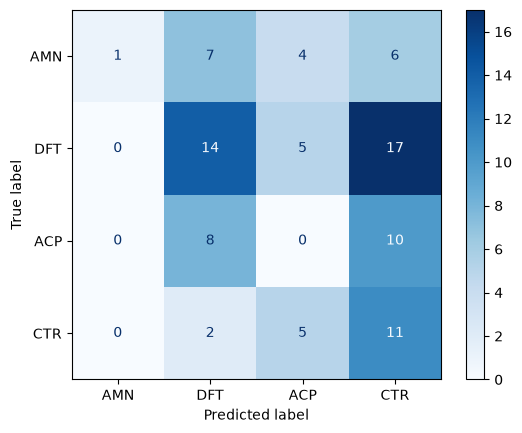

In [101]:
from sklearn.metrics import ConfusionMatrixDisplay

classifier = clf_rf.fit(trainX_rf, trainy_rf)
class_names = ['AMN', 'DFT', 'ACP', 'CTR']

disp = ConfusionMatrixDisplay.from_estimator(
        classifier,
        testX_rf,
        testy_rf,
        display_labels=class_names,
        cmap=plt.cm.Blues
)

plt.show()

#### Balanced accuracy

In [103]:
from sklearn.metrics import balanced_accuracy_score

y_pred = clf_rf.predict(testX_rf)

balanced_accuracy_score(testy_rf, y_pred, adjusted=True)

0.018518518518518528

### Make pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC

numeric_features = ['RDX_min', 'RDX_lat_min', 'RDX_max', 'RDX_lat_max', 'RDX_grad', 'RDX2_min', 'RDX2_max']

numeric_transformer = Pipeline([
    ('scaler', RobustScaler())
])

ct = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features)], 
    remainder='passthrough')

ct.fit_transform(X_train)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report

pipeline = make_pipeline(RobustScaler(), LogisticRegression(random_state=42))

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)

predictions

accuracy = pipeline.score(X_test, y_test)
print ("Accuracy is {}".format(accuracy))

print(classification_report(y_test, predictions))

Accuracy is 0.3111111111111111
              precision    recall  f1-score   support

         ACP       0.00      0.00      0.00        36
         AMN       0.28      0.46      0.35        24
         CTR       0.23      0.50      0.32         6
         DFT       0.37      0.58      0.45        24

    accuracy                           0.31        90
   macro avg       0.22      0.39      0.28        90
weighted avg       0.19      0.31      0.23        90



/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

### Apply pipeline

In [ ]:
clf.fit(X_train, y_train)
prediction = clf.predict(X_test)
accuracy = clf.score(X_test, y_test)
print(f'{accuracy:.3f}')

0.289


### Optuna test

In [ ]:
import optuna

from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

def objective(trial):
    classifier_name = trial.suggest_categorical('classifier', ['SVC', 'RandomForest'])
    if classifier_name == 'SVC':
        svc_c = trial.suggest_float('svc_c', 1e-10, 1e10, log=True)
        classifier_obj = SVC(C=svc_c, gamma='auto')
    else:
        rf_max_depth = trial.suggest_int('rf_max_depth', 2, 32, log=True)
        classifier_obj = RandomForestClassifier(max_depth=rf_max_depth, n_estimators=10)

    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print(f'BEST: {study.best_params}')





# svm = SVC()

# p_grid = {"C": [1, 10, 100], "gamma": [0.01, 0.1], "kernel": {'linear', 'poly', 'rbf'}}

# outer_cv = GroupKFold(n_splits=3)
# inner_cv = GroupKFold(n_splits=5)

# scores = []

# for train_idx, test_idx in outer_cv.split(X, y, groups=id):
#     X_train_outer, X_test_outer = X[train_idx], X[test_idx]
#     y_train_outer, y_test_outer = y[train_idx], y[test_idx]

#     clf = GridSearchCV(estimator=svm, param_grid=p_grid, cv=inner_cv)
#     clf.fit(X_train_outer, X_train_outer)
#     scores.append(clf.best_score_)



[I 2026-09-03 19:21:54,100] A new study created in memory with name: no-name-ba5438a9-583c-4301-a983-243161536d01
[I 2026-09-03 19:21:54,102] Trial 0 finished with value: 0.28888888888888886 and parameters: {'classifier': 'SVC', 'svc_c': 1.5348130218959242e-09}. Best is trial 0 with value: 0.28888888888888886.
[I 2026-09-03 19:21:54,102] Trial 1 finished with value: 0.28888888888888886 and parameters: {'classifier': 'RandomForest', 'rf_max_depth': 2}. Best is trial 0 with value: 0.28888888888888886.
[I 2026-09-03 19:21:54,103] Trial 2 finished with value: 0.28888888888888886 and parameters: {'classifier': 'SVC', 'svc_c': 1.2253276580020046e-09}. Best is trial 0 with value: 0.28888888888888886.
[I 2026-09-03 19:21:54,104] Trial 3 finished with value: 0.28888888888888886 and parameters: {'classifier': 'RandomForest', 'rf_max_depth': 8}. Best is trial 0 with value: 0.28888888888888886.
[I 2026-09-03 19:21:54,104] Trial 4 finished with value: 0.28888888888888886 and parameters: {'classifie

BEST: {'classifier': 'SVC', 'svc_c': 1.5348130218959242e-09}


#### TEST
- transformer: preprocessing
- estimator: model

##### Breakdown
- Step 1: test different base models (SVM, RandomForest, LogisticRegression, XGboost) -> use a DummyClassifier as reference to chance
- Step 2: choose the best model and optimise it

Figure out a clear modelling pipeline